Downloading some important libraries, fixing the plotting and saving of figures

In [1]:
# setting up / configuring 
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# setting the plot dpi 
#plt.rcParams['figure.dpi']= 1000

# Common imports
import numpy as np
import os

# pandas
import pandas as pd

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "training_linear_models"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=800):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Reading the csv file using pandas, saving the data as a dataframe, and removing outlier values from the dataset to improve the performance of the models. 


In [32]:
# reading the csv file and printing the head 
df = pd.read_csv("C:/Users/andsa/Documents/ML/concrete_data.csv")  
#df.head()

print(df.describe())
##df.info()
#desc = df.describe()
#print(desc)


# Checking for correlation 
#corr_matrix = df.corr()
#corr_matrix["Strength"]


# Beregn Q1, Q3 og IQR
#Q1 = df.quantile(0.25)
#Q3 = df.quantile(0.75)
#IQR = Q3 - Q1
# Sett grenser
#lower_bound = Q1 - 1.5 * .2* IQR
#upper_bound = Q3 + 1.5 * .2* IQR
# Filtrer ut avvik
#df_cleaned = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]


# Beregn 5% og 90% percentiler
#lower_bound = df.quantile(0.05)
#upper_bound = df.quantile(0.90)  # Strammer inn den øvre grensen
# Filtrer ut avvik
#df_cleaned = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]


# Beregn gjennomsnitt og standardavvik
mean = df.mean()
std_dev = df.std()
# Sett strammere grenser
lower_bound = mean - 1.5 * std_dev
upper_bound = mean + 1.5 * std_dev
# Filtrer ut avvik
df_cleaned = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]


# looking as a histogram of the params 
#df.hist()
#df_cleaned.hist()


# checking for changes 
#print(df_cleaned.describe())


            Cement  Blast Furnace Slag      Fly Ash        Water  \
count  1030.000000         1030.000000  1030.000000  1030.000000   
mean    281.167864           73.895825    54.188350   181.567282   
std     104.506364           86.279342    63.997004    21.354219   
min     102.000000            0.000000     0.000000   121.800000   
25%     192.375000            0.000000     0.000000   164.900000   
50%     272.900000           22.000000     0.000000   185.000000   
75%     350.000000          142.950000   118.300000   192.000000   
max     540.000000          359.400000   200.100000   247.000000   

       Superplasticizer  Coarse Aggregate  Fine Aggregate          Age  \
count       1030.000000       1030.000000     1030.000000  1030.000000   
mean           6.204660        972.918932      773.580485    45.662136   
std            5.973841         77.753954       80.175980    63.169912   
min            0.000000        801.000000      594.000000     1.000000   
25%            0.

           Cement  Blast Furnace Slag     Fly Ash       Water  \
count  435.000000          435.000000  435.000000  435.000000   
mean   266.590115           56.422299   58.458391  182.695402   
std     72.057980           71.202797   56.525455   13.634416   
min    133.000000            0.000000    0.000000  154.000000   
25%    212.900000            0.000000    0.000000  174.800000   
50%    272.800000            0.000000   82.000000  185.700000   
75%    321.150000          129.800000  118.200000  192.000000   
max    424.000000          200.000000  150.000000  213.500000   

       Superplasticizer  Coarse Aggregate  Fine Aggregate         Age  \
count        435.000000        435.000000      435.000000  435.000000   
mean           5.562299        985.514943      784.033103   32.579310   
std            4.479467         59.708509       49.072018   28.779313   
min            0.000000        860.000000      655.000000    3.000000   
25%            0.000000        944.700000      75

array([[<AxesSubplot:title={'center':'Cement'}>,
        <AxesSubplot:title={'center':'Blast Furnace Slag'}>,
        <AxesSubplot:title={'center':'Fly Ash'}>],
       [<AxesSubplot:title={'center':'Water'}>,
        <AxesSubplot:title={'center':'Superplasticizer'}>,
        <AxesSubplot:title={'center':'Coarse Aggregate'}>],
       [<AxesSubplot:title={'center':'Fine Aggregate'}>,
        <AxesSubplot:title={'center':'Age'}>,
        <AxesSubplot:title={'center':'Strength'}>]], dtype=object)

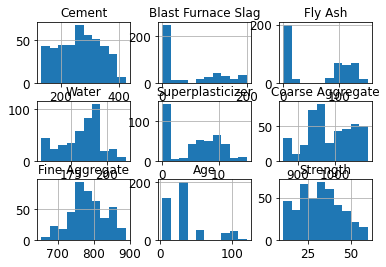

In [33]:
# checking for changes 
#print(df_cleaned.describe())
des = df_cleaned.describe()
print(des)

df_cleaned.hist()

Assigning columns to the input and output variables X and y.

In [28]:
# assigning the X and y values 
X = df[['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']]
y = df[['Strength']]


Importing libraries to split the data into a training and a test set, with 80 percent of the data used for training, and 20 percent used for testing. Also scaling the data, wich is important for all but the simple OLS. 

In [29]:
# importing test metrics 
from sklearn.metrics import mean_squared_error, r2_score

# importing a splitter for the data 
from sklearn.model_selection import train_test_split

# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scaling the data - think this won't allow the same pairs in test and train, scaling is important for the SGD regressor 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# checking for skewness of the strength distribution 
#from scipy.stats import skew
#skewness = skew(df['Strength'])
#print(skewness)




Creating and fitting a linear OLS and SGD model to the training data, to compare results. 

In [30]:
# Doing an ordinary least squares regression -> OLS 
from sklearn.linear_model import LinearRegression
lin_reg_OLS = LinearRegression()
# fitting the OLS model to the training data
lin_reg_OLS.fit(X_train, y_train)


# Doing a stochastic gradient descent method -> SGD, with max interations of 1000, eta of .01, and a constant learning rate 
from sklearn.linear_model import SGDRegressor
lin_reg_SGD = SGDRegressor(max_iter=1000, eta0=0.01, learning_rate="constant")
# fitting the SGD model to the training data 
lin_reg_SGD.fit(X_train_scaled, y_train)

c:\Users\andsa\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


SGDRegressor(learning_rate='constant')

Predicting strength values with both models, and printing metrics to gauge performance. 

OLS Regression:
R² Score: 0.6276
MSE: 95.97

SGD Regression:
R² Score: 0.63
MSE: 96.39



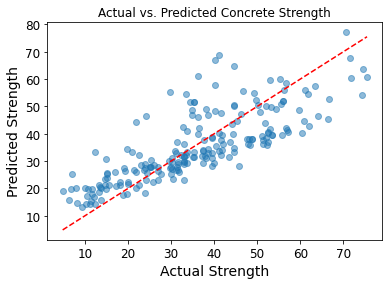

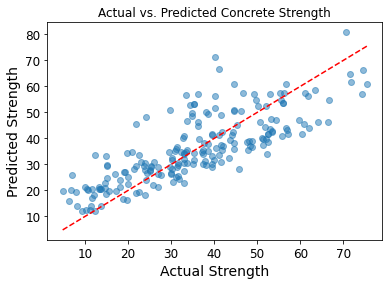

In [31]:
# Predicting strength values on the testing set for both models.  
y_pred_OLS = lin_reg_OLS.predict(X_test)
y_pred_SGD = lin_reg_SGD.predict(X_test_scaled)


# printing the metrics for the OLS model 
print("OLS Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_OLS), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_OLS), 2)}\n")


# printing the metrics for the SGD model 
print("SGD Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_SGD), 2)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_SGD), 2)}\n")

plt.scatter(y_test, y_pred_OLS, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()


plt.scatter(y_test, y_pred_SGD, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

Tuning the hyperparameters of a linear SGD model by using grid_search 

c:\Users\andsa\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Best Parameters: {'eta0': 0.1, 'learning_rate': 'adaptive', 'max_iter': 500}
SGD Regression with hyperparameter tuning:
R² Score: 0.6279
MSE: 95.87



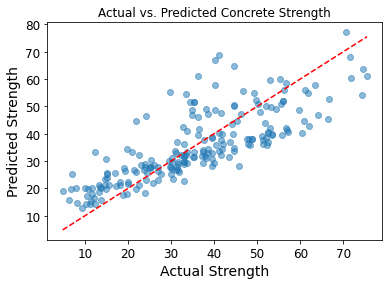

In [28]:
# importing the grid search feature to optimize the params for SGD
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid with some values
params_for_grid = {
    "eta0": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],  # More values
    "max_iter": [500, 1000, 1500, 2000, 3000, 5000],  # Increased range
    "learning_rate": ["constant", "optimal", "invscaling", "adaptive"]
}

# Creating the SGD regressor
SGD = SGDRegressor(random_state=42)

# Perform Grid Search, dividing into 5 folds -> cv = 5, using all CPU cores to speed it up -> n_jobs = -1 
grid_search = GridSearchCV(SGD, params_for_grid, cv=5, n_jobs = -1)
grid_search.fit(X_train_scaled, y_train)

# Getting the best model from the grid search
best_SGD = grid_search.best_estimator_

# Predicting on the test set
y_pred_SGD_optimized = best_SGD.predict(X_test_scaled)


# Printing the results for the "optimal" SGD model and it's parameters 
print("Best Parameters:", grid_search.best_params_)


# printing the metrics for the tunged SGD model 
print("SGD Regression with hyperparameter tuning:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_SGD_optimized), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_SGD_optimized), 2)}\n")

plt.scatter(y_test, y_pred_SGD_optimized, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

Creating a polynomial regressor to try to better fit the training data.

Simple polynomial Regression:
R² Score: 0.8436
MSE: 40.31



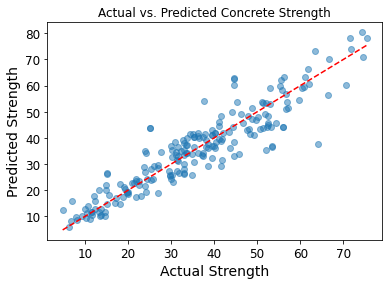

In [25]:
# polynomial regression 
from sklearn.preprocessing import PolynomialFeatures


poly_features = PolynomialFeatures(degree = 3)
X_poly_train = poly_features.fit_transform(X_train_scaled)
X_poly_test = poly_features.transform(X_test_scaled)


lin_reg_for_poly = LinearRegression()
lin_reg_for_poly.fit(X_poly_train, y_train)

y_pred_poly = lin_reg_for_poly.predict(X_poly_test)

print("Simple polynomial Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_poly), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_poly), 2)}\n")


plt.scatter(y_test, y_pred_poly, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()


Trying out a polynomial Lasso regression with hyperparameter tuning, going through multiple different degrees. 

c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 36.23181329001818, tolerance: 18.122231624066767
  model = cd_fast.enet_coordinate_descent(
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22.360125129496737, tolerance: 18.43498033201821
  model = cd_fast.enet_coordinate_descent(
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 39.144356608594535, tolerance: 19.060978618846736
  model = cd_fast.enet_coordinate_descent(
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWa

Best Parameters: {'poly__degree': 5, 'regressor__alpha': 0.1, 'regressor__fit_intercept': True}
R² Score: 0.8336
MSE: 42.8832


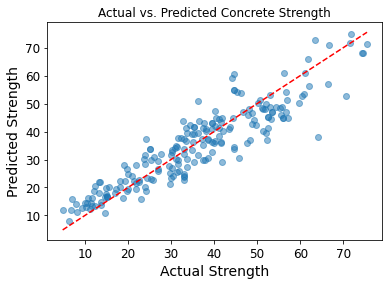

In [27]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Create a pipeline with PolynomialFeatures, StandardScaler, and Lasso regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),    # Polynomial features
    ('scaler', StandardScaler()),      # Scaling the features
    ('regressor', Lasso())             # Lasso regression
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],       # Degrees of the polynomial
    'regressor__alpha': [0.1, 0.5, 1.0, 10],  # Regularization strength for Lasso
    'regressor__fit_intercept': [True, False]  # Whether or not to fit the intercept term
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model using the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Predict using the best model
y_pred_lasso_grid = grid_search.predict(X_test)

# Evaluate the model
print(f"R² Score: {np.round(r2_score(y_test, y_pred_lasso_grid), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_lasso_grid), 4)}")


plt.scatter(y_test, y_pred_lasso_grid, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

Doing the some for a RandomForestRegressor. (dropping it, didn't finnish after +45 mins)

In [26]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Create a pipeline with PolynomialFeatures, StandardScaler, and RandomForestRegressor
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),    # Polynomial features
    ('scaler', StandardScaler()),      # Scaling the features
    ('regressor', RandomForestRegressor())  # Random Forest regressor
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],          # Degrees of the polynomial
    'regressor__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'regressor__max_depth': [None, 10, 20, 30],  # Maximum depth of the trees
    'regressor__min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'regressor__min_samples_leaf': [1, 2, 4]     # Minimum number of samples required to be at a leaf node
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs = -1)

# Fit the model using the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Predict using the best model
y_pred_rf_grid = grid_search.predict(X_test)

# Evaluate the model
print(f"R² Score: {np.round(r2_score(y_test, y_pred_rf_grid), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_rf_grid), 4)}")


c:\Users\andsa\anaconda3\lib\site-packages\sklearn\pipeline.py:346: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\pipeline.py:346: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\pipeline.py:346: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\pipeline.py:346: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Plea

KeyboardInterrupt: 